# 1. Importar Librerias Necesarias

In [14]:
import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# 2. Carga y limpieza inicial del dataset
Origen: Datos recopilados en Italia por un dispositivo multisensor químico de calidad del aire.

Duración: De marzo de 2004 a febrero de 2005 (1 año completo).

Instancias: 9358 registros horarios.

**Variables incluidas**

Contiene:

Lecturas de sensores químicos: 5 sensores de óxidos metálicos que detectan gases contaminantes.

Concentraciones reales (Ground Truth):

Monóxido de carbono (CO)

Hidrocarburos no metánicos (NMHC)

Benceno (C₆H₆)

Óxidos de nitrógeno (NOx)

Dióxido de nitrógeno (NO₂)

Variables meteorológicas: Temperatura, humedad relativa, presión atmosférica.


In [15]:
data = pd.read_csv("AirQualityUCI.csv", sep=';', decimal=',', encoding='latin1')
data = data.loc[:, ~data.columns.str.startswith('Unnamed')]

# 3. Procesamiento de columnas temporales


In [16]:
data['datetime'] = pd.to_datetime(
    data['Date'] + ' ' + data['Time'],
    format='%d/%m/%Y %H.%M.%S',
    errors='coerce'
)
data = data.drop(columns=['Date', 'Time'])
cols = ['datetime'] + [c for c in data.columns if c != 'datetime']
data = data[cols]


# 4. Separación de variables predictoras y objetivo

In [17]:
y = data['CO(GT)'].copy()
X = data.drop(columns=['CO(GT)']).copy()


# 5. Ingeniería de variables temporales

In [18]:
X['year'] = X['datetime'].dt.year
X['month'] = X['datetime'].dt.month
X['day'] = X['datetime'].dt.day
X['hour'] = X['datetime'].dt.hour
X['weekday'] = X['datetime'].dt.weekday

if 'datetime' in X.columns:
    X = X.drop(columns=['datetime'])


# 6. Imputación de valores faltantes

In [19]:
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

y_imputer = SimpleImputer(strategy='mean')
y_imputed = pd.Series(y_imputer.fit_transform(y.values.reshape(-1,1)).ravel(), index=y.index)


# 7. División en conjunto de entrenamiento y prueba

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y_imputed, test_size=0.2, random_state=42, shuffle=True
)


# 8. Escalado de variables

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 9. Conversión a tensores para PyTorch

In [22]:
X_train_np = np.array(X_train_scaled, dtype=np.float32)
X_test_np = np.array(X_test_scaled, dtype=np.float32)
y_train_np = np.array(y_train, dtype=np.float32)
y_test_np = np.array(y_test, dtype=np.float32)

# Mover los tensores a CUDA si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_t = torch.tensor(X_train_np, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_np, dtype=torch.float32).to(device)
Y_train_t = torch.tensor(y_train_np.reshape(-1,1), dtype=torch.float32).to(device)
Y_test_t = torch.tensor(y_test_np.reshape(-1,1), dtype=torch.float32).to(device)

print(f"Using device: {device}")

Using device: cuda


# 10. Definición del modelo de regresión

In [23]:
D_in = X_train_t.shape[1]
H_1, H_2, H_3 = 64, 32, 16
D_out = 1
model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H_1),
    torch.nn.ReLU(),
    torch.nn.Linear(H_1, H_2),
    torch.nn.ReLU(),
    torch.nn.Linear(H_2, H_3),
    torch.nn.ReLU(),
    torch.nn.Linear(H_3, D_out)
).to(device) # Mover el modelo a CUDA

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 11. Entrenamiento del modelo

In [24]:
epochs = 4000
log_each = 200
losses = []
model.train()

for e in range(1, epochs + 1):
    y_pred = model(X_train_t)
    loss = criterion(y_pred, Y_train_t)
    losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if e % log_each == 0:
        print(f"Epoch {e}/{epochs}, Loss (avg last {log_each}): {np.mean(losses):.6f}")
        losses = []

Epoch 200/4000, Loss (avg last 200): 5231.513610
Epoch 400/4000, Loss (avg last 200): 2741.060389
Epoch 600/4000, Loss (avg last 200): 2424.915620
Epoch 800/4000, Loss (avg last 200): 1989.123132
Epoch 1000/4000, Loss (avg last 200): 1541.577584
Epoch 1200/4000, Loss (avg last 200): 1246.121696
Epoch 1400/4000, Loss (avg last 200): 1073.886858
Epoch 1600/4000, Loss (avg last 200): 954.494946
Epoch 1800/4000, Loss (avg last 200): 856.417843
Epoch 2000/4000, Loss (avg last 200): 777.328579
Epoch 2200/4000, Loss (avg last 200): 711.786275
Epoch 2400/4000, Loss (avg last 200): 659.271356
Epoch 2600/4000, Loss (avg last 200): 618.271747
Epoch 2800/4000, Loss (avg last 200): 582.718004
Epoch 3000/4000, Loss (avg last 200): 554.234711
Epoch 3200/4000, Loss (avg last 200): 532.080775
Epoch 3400/4000, Loss (avg last 200): 513.233428
Epoch 3600/4000, Loss (avg last 200): 497.072735
Epoch 3800/4000, Loss (avg last 200): 482.767314
Epoch 4000/4000, Loss (avg last 200): 469.619680


# 12. Evaluación del modelo

In [25]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_t).cpu().numpy().ravel() # Mover la predicción a la CPU para calcular MSE

mse = mean_squared_error(y_test_np, y_pred_test)
print(f"\nMSE en test: {mse:.6f}")

print("\nPrimeros 10: Actual - Predicción")
for i in range(min(10, len(y_test_np))):
    print(f"{y_test_np[i]:.3f}  -  {y_pred_test[i]:.3f}")


MSE en test: 1450.462524

Primeros 10: Actual - Predicción
0.700  -  12.440
2.100  -  1.962
3.400  -  3.943
1.000  -  14.754
-200.000  -  -3.391
-200.000  -  -204.121
4.800  -  7.015
-200.000  -  -189.544
1.800  -  -2.984
2.200  -  -1.628


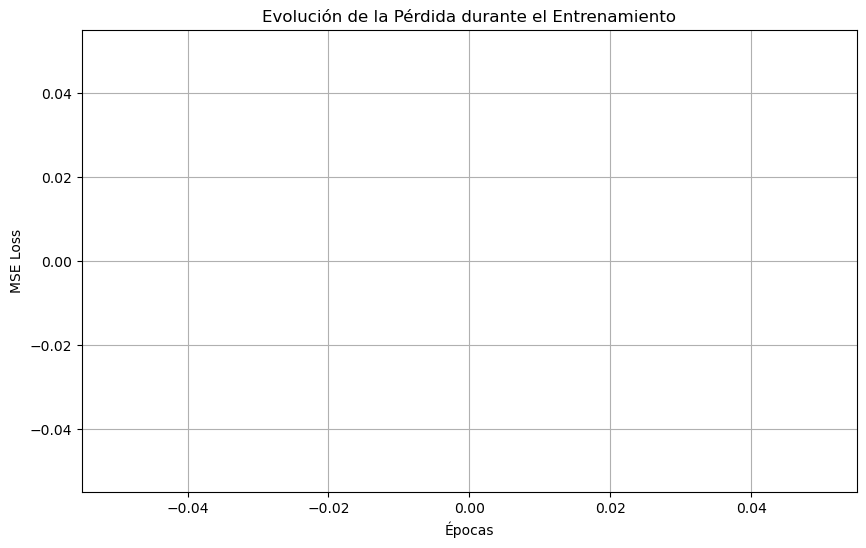

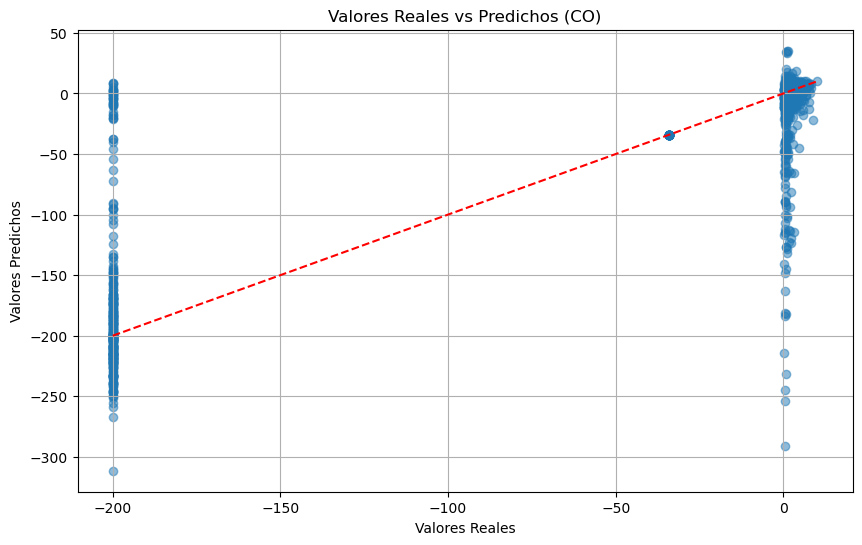

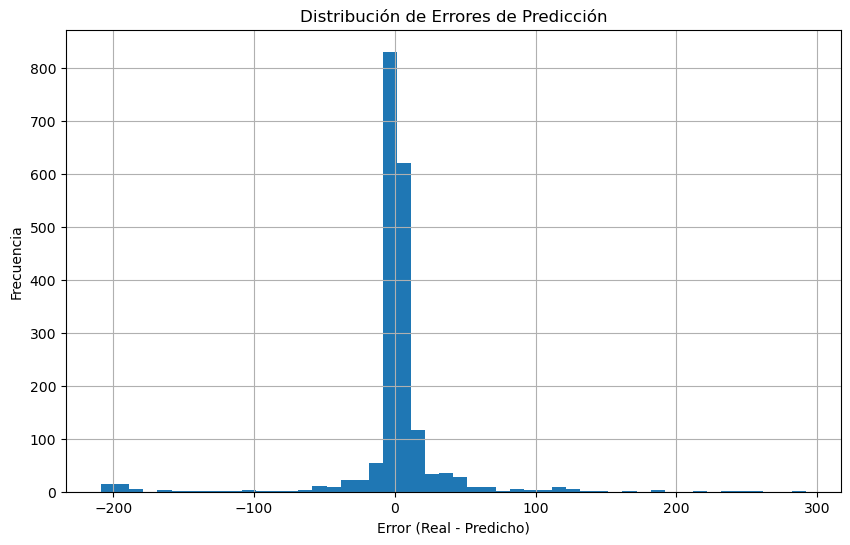

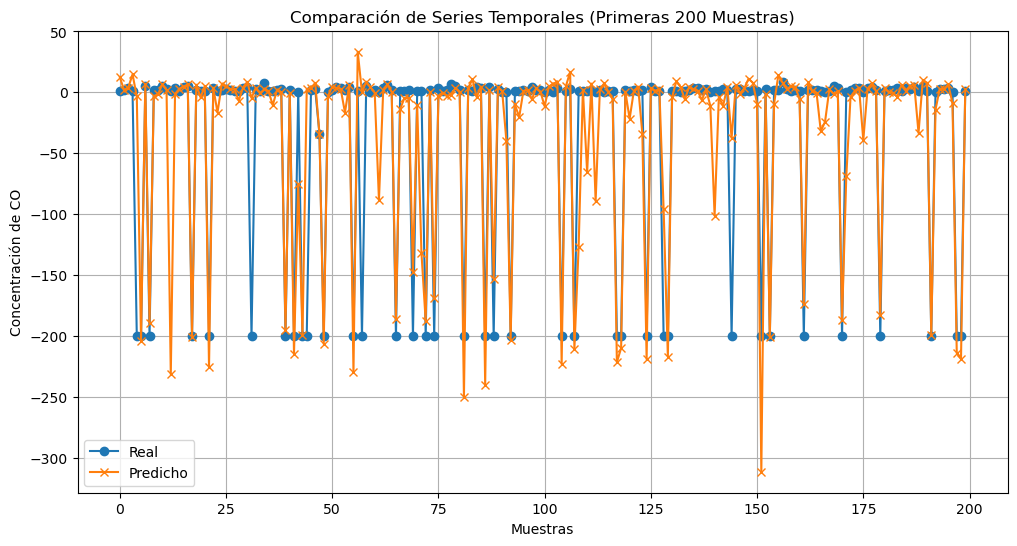

In [26]:
import matplotlib.pyplot as plt

# Gráfica de pérdida durante el entrenamiento
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Evolución de la Pérdida durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

# Gráfica de valores reales vs predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_test_np, y_pred_test, alpha=0.5)
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--')
plt.title('Valores Reales vs Predichos (CO)')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.grid(True)
plt.show()

# Gráfica de distribución de errores
errors = y_test_np - y_pred_test
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=50)
plt.title('Distribución de Errores de Predicción')
plt.xlabel('Error (Real - Predicho)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# Gráfica de series temporales (primeras 200 muestras)
plt.figure(figsize=(12, 6))
plt.plot(y_test_np[:200], label='Real', marker='o')
plt.plot(y_pred_test[:200], label='Predicho', marker='x')
plt.title('Comparación de Series Temporales (Primeras 200 Muestras)')
plt.xlabel('Muestras')
plt.ylabel('Concentración de CO')
plt.legend()
plt.grid(True)
plt.show()